In [1]:
import pandas as pd 

# Stock price data
def get_stock(tickers: list, year: str):
    dfs = dict()
    for ticker in tickers:
        df_stock = pd.read_csv(f's3://us-options-historical/stocks/{ticker}_{year}.csv.zst')
        dfs[ticker] = pd.Series(data=df_stock["close"].values, index=df_stock["timestamp"].values).copy()
    df = pd.concat(dfs, axis=1)
    df["date"] = pd.to_datetime(df.index).date
    return df

<Axes: xlabel='date'>

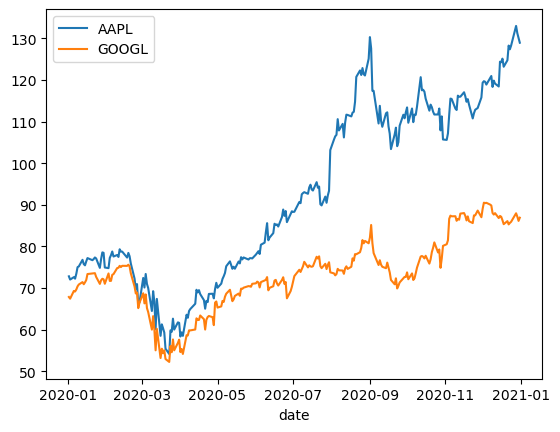

In [2]:
df = get_stock(["AAPL", "GOOGL"], "2020")
df.sort_index().groupby("date").last().plot()

<Axes: title={'center': 'Historical correlation'}, xlabel='date'>

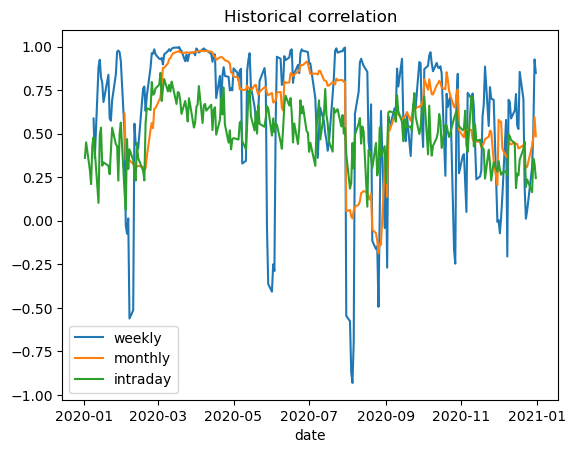

In [25]:
# Correlation
df_histcorr_weekly = df.sort_index().groupby("date").last().diff().rolling(5).corr().unstack()["AAPL","GOOGL"]
df_histcorr_monthly = df.sort_index().groupby("date").last().diff().rolling(21).corr().unstack()["AAPL","GOOGL"]
df_histcorr_intraday = df.sort_index().groupby("date").apply(lambda x: x.diff().corr().unstack()["AAPL","GOOGL"])

pd.concat({
    "weekly" : df_histcorr_weekly,
    "monthly" : df_histcorr_monthly,
    "intraday" : df_histcorr_intraday,
    }, axis=1).plot(title="Historical correlation")

In [26]:
# return correlation seems persistent. 
# 1) How to measure it? 
# 2) How to use it?